# LightGBM Modeling

Train and evaluate a LightGBM classifier to predict nucleotide changes in DENV genome regions (E, 5′UTR, 3′UTR) using environmental data (temperature, CO₂), as part of a comparative study for climate-aware viral evolution forecasting.

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)

import joblib

### Load processed data

In [2]:
df = pd.read_csv('../data/processed_genomic_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (359, 2017)


,Avg_Temp_C,CO2_Emission_Mt,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,...,p_2006,p_2007,p_2008,p_2009,p_2010,p_2011,p_2012,p_2013,p_2014,p_2015
0,26.16,2489.9,4,4,3,1,4,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
2,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
3,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
4,26.16,2489.9,4,3,2,3,3,1,4,4,...,0,0,0,0,0,0,0,0,0,0


### Define features and targets (X & y)

In [3]:
feature_cols = df.columns[:2]        
target_cols = df.columns[2:]         

X = df[feature_cols]
y = df[target_cols]

print("Shape of X (features):", X.shape)
print("Shape of y (targets):", y.shape)

Shape of X (features): (359, 2)
Shape of y (targets): (359, 2015)


### Train-Test Split

In [4]:
# 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 251
Test set size: 108


In [5]:
n_targets = y_train.shape[1]
dummy = pd.DataFrame(np.zeros((5, n_targets)), columns=y_train.columns, dtype=int)
for i in range(n_targets):
    dummy.iloc[:, i] = np.arange(5)

X_train_lgb = pd.concat([X_train, X_train.iloc[:5, :]], ignore_index=True)
y_train_lgb = pd.concat([y_train, dummy], ignore_index=True)

### LightGBM Model Training
LightGBM was implemented using a multi-output classifier wrapper to enable simultaneous prediction of all 2015 nucleotide positions.

In [6]:
lgb_base = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=2,
    verbose=-1
)

# Multi-output wrapper
lgb_multi = MultiOutputClassifier(lgb_base, n_jobs=-1)

# Fit the Model
lgb_multi.fit(X_train_lgb, y_train_lgb)

MultiOutputClassifier(estimator=LGBMClassifier(colsample_bytree=0.8,
                                               max_depth=7, n_jobs=2,
                                               random_state=42, subsample=0.8,
                                               verbose=-1),
                      n_jobs=-1)

**Model Hyperparameter Choices:**

- `n_estimators=100`:  
  The number of boosting rounds is set to 100, providing a balance between predictive accuracy and computational efficiency. More estimators can improve model performance but also increase training time and risk of overfitting, especially in smaller datasets.

- `max_depth=7`:  
  The maximum tree depth is restricted to 7 to prevent overfitting on a dataset of modest size. Limiting tree depth encourages the model to focus on learning the most significant and generalizable splits, rather than memorizing noise.

- `learning_rate=0.1`:  
  The learning rate is set to 0.1, a commonly used default that ensures each boosting round makes an incremental contribution to learning, thus improving convergence stability and reducing the risk of overshooting optimal solutions.

- `subsample=0.8`:  
  At each boosting iteration, 80% of the training data is randomly sampled. This subsampling introduces beneficial randomness, helping to regularize the model and enhance its robustness to overfitting.

- `colsample_bytree=0.8`:  
  For each tree, a random subset (80%) of features is used, further promoting model diversity and regularization. This is especially useful in multi-output tasks to avoid over-reliance on any single predictor.

- `random_state=42`:  
  The random seed is fixed for reproducibility, ensuring that results can be reliably compared across different algorithms and experimental runs.

- `n_jobs=2`:  
  Parallel processing is limited to 2 CPU cores to ensure stable performance and efficient resource utilization, based on hardware and session constraints.

- `verbose=-1`:  
  Verbose output is suppressed to produce a cleaner training log and reduce unnecessary warnings.

*As with the other models in this study, comprehensive hyperparameter optimization (e.g., grid search or Bayesian optimization) is reserved for future research to maintain focus on core research objectives and computational simplicity.*

### Model Evaluation

#### Predict on test set

In [7]:
y_pred = lgb_multi.predict(X_test)

#### Overall accuracy

In [8]:
overall_accuracy = (y_pred == y_test.values).mean()
print(f"Overall nucleotide-level accuracy: {overall_accuracy:.3f}")

Overall nucleotide-level accuracy: 0.460


#### Per-position accuracy

In [9]:
per_position_accuracy = (y_pred == y_test.values).mean(axis=0)
per_position_df = pd.DataFrame({
    'position': target_cols,
    'accuracy': per_position_accuracy
})
print(per_position_df.head())

  position  accuracy
0      p_1  0.555556
1      p_2  0.462963
2      p_3  0.564815
3      p_4  0.629630
4      p_5  0.611111


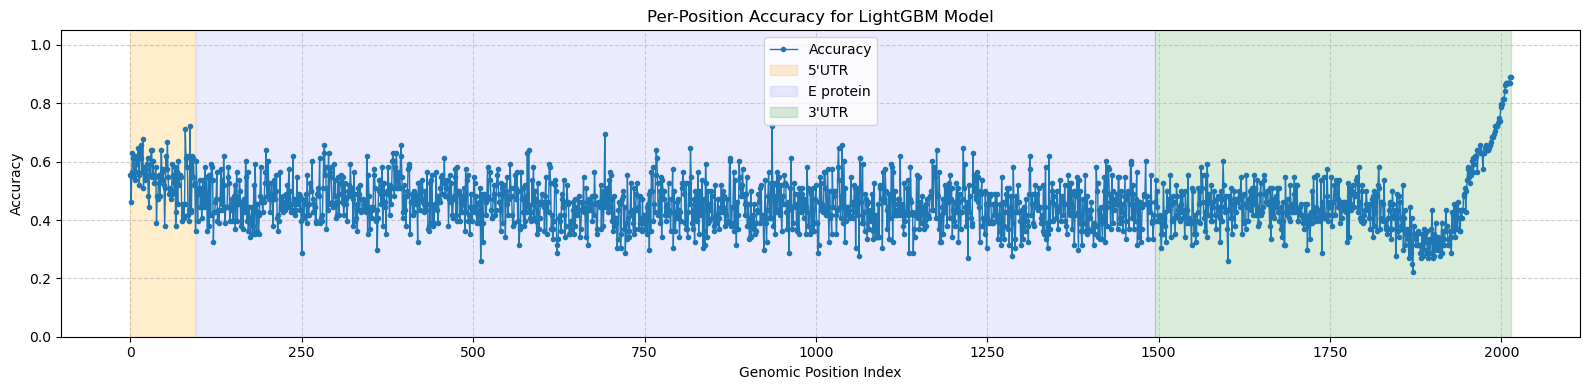

In [10]:
# Plot per-position accuracy with region labels (E, 5′UTR, 3′UTR)
utr5_start, utr5_end = 0, 94       
e_start, e_end = 95, 1494          
utr3_start, utr3_end = 1495, 2014  

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), per_position_accuracy, marker='.', linestyle='-', linewidth=1, label='Accuracy')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per-Position Accuracy for LightGBM Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Accuracy for LightGBM Model

The above plot illustrates the per-position nucleotide prediction accuracy of the LightGBM model across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. Each data point reflects the accuracy of nucleotide prediction at a specific genomic position on the test set, with colored background regions denoting the three main functional genome segments (5′UTR, E protein, 3′UTR).

#### Key Insights:

- **Overall performance:**  
  The LightGBM model achieves consistently moderate to high accuracy across most nucleotide positions, with accuracy values generally spanning 0.35 to 0.6. This robust performance further confirms the effectiveness of gradient boosting methods for multi-class nucleotide prediction tasks using environmental features.

- **5′UTR (orange, left):**  
  The accuracy profile within the 5′UTR shows moderate variability but maintains alignment with the patterns observed in the E protein region. The lack of extreme outliers suggests that environmental predictors have informative value even in the regulatory regions of the genome.

- **Envelope (E) protein (blue, center):**  
  Prediction accuracy in the E protein region remains broadly stable, with minor fluctuations reflecting the biological complexity and diversity of this segment. The stability of performance here supports the generalizability of LightGBM across different genomic landscapes.

- **3′UTR (green, right):**  
  A pronounced upward trend in accuracy is observed at the terminal end of the 3′UTR, where the model achieves its highest per-position accuracy. This likely corresponds to highly conserved sites or padded positions, which are easier to classify accurately.

- **Difficult-to-predict positions:**  
  As with other models, some positions across the genome exhibit lower accuracy, which may be due to mutation hotspots, rare nucleotide occurrences, or limited informativeness of the environmental predictors for those specific sites.

In [11]:
# Save per-position accuracy
per_position_df.to_csv('../results/lgb_per_position_accuracy.csv', index=False)

#### Calculate per-position Classification Report and Confusion Matrix

In [12]:
report_list = []
conf_matrix_list = []

for idx, col in enumerate(target_cols):
    y_true_col = y_test[col]
    y_pred_col = y_pred[:, idx]
    report = classification_report(y_true_col, y_pred_col, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_col, y_pred_col)

    # Flattened classification report (main averages and support)
    row = {
        'position': col,
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall'],
        'support': report['weighted avg']['support']
    }
    # Per-class F1
    for base in ['0', '1', '2', '3', '4']:  # Adjust base labels as in your data
        if base in report:
            row[f'f1_{base}'] = report[base]['f1-score']
            row[f'precision_{base}'] = report[base]['precision']
            row[f'recall_{base}'] = report[base]['recall']
            row[f'support_{base}'] = report[base]['support']
    report_list.append(row)

    # Confusion matrix as a flattened string (or as a nested list)
    conf_matrix_list.append({
        'position': col,
        'confusion_matrix': cm.tolist()
    })

# Convert lists to DataFrames
report_df = pd.DataFrame(report_list)
conf_matrix_df = pd.DataFrame(conf_matrix_list)

In [13]:
report_df.head()

,position,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,support,f1_1,precision_1,...,recall_3,support_3,f1_4,precision_4,recall_4,support_4,f1_0,precision_0,recall_0,support_0
0,p_1,0.348638,0.351876,0.351719,0.530756,0.513372,0.555556,108.0,0.696970,0.647887,...,0.375000,24.0,0.000000,0.000000,0.000000,5.0,NaN,NaN,NaN,NaN
1,p_2,0.359996,0.370238,0.398496,0.403401,0.391358,0.462963,108.0,0.595745,0.500000,...,0.571429,28.0,0.387097,0.600000,0.285714,21.0,NaN,NaN,NaN,NaN
2,p_3,0.489319,0.611911,0.478119,0.523664,0.553797,0.564815,108.0,0.571429,1.000000,...,0.090909,22.0,0.679612,0.573770,0.833333,42.0,NaN,NaN,NaN,NaN
3,p_4,0.396634,0.390385,0.412842,0.568777,0.526140,0.629630,108.0,0.428571,0.461538,...,0.000000,14.0,0.363636,0.400000,0.333333,18.0,NaN,NaN,NaN,NaN
4,p_5,0.305526,0.318627,0.336941,0.486314,0.422476,0.611111,108.0,0.000000,0.000000,...,0.984127,63.0,0.470588,0.666667,0.363636,11.0,NaN,NaN,NaN,NaN


In [14]:
conf_matrix_df.head()

,position,confusion_matrix
0,p_1,"[[46, 5, 10, 0], [9, 5, 4, 0], [13, 2, 9, 0], ..."
1,p_2,"[[28, 0, 10, 0], [12, 0, 7, 2], [10, 0, 16, 2]..."
2,p_3,"[[4, 3, 0, 3], [0, 20, 3, 11], [0, 8, 2, 12], ..."
3,p_4,"[[6, 7, 0, 2], [4, 56, 0, 1], [1, 7, 0, 6], [2..."
4,p_5,"[[0, 0, 14, 1], [0, 0, 19, 0], [0, 0, 62, 1], ..."


#### Plot Macro F1 from classification report

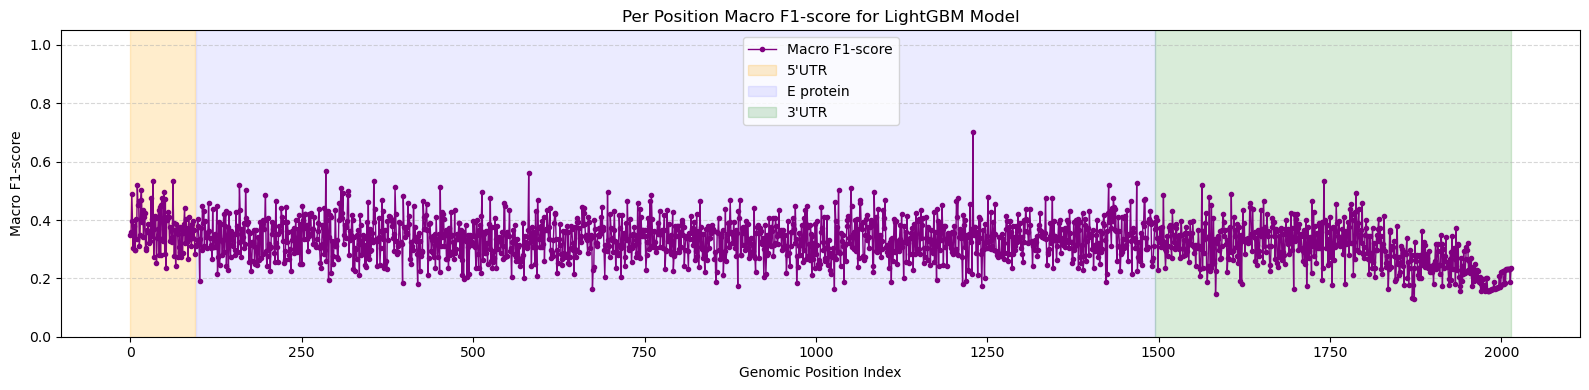

In [15]:
# Extract macro F1 for all positions
positions = report_df['position']
macro_f1 = report_df['macro_f1']

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), macro_f1, marker='.', linestyle='-', linewidth=1, color='purple', label='Macro F1-score')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per Position Macro F1-score for LightGBM Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Macro F1-score')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Macro F1-score for LightGBM Model

The above plot shows the macro-averaged F1-score for each nucleotide position as predicted by the LightGBM model, spanning the 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. The macro F1-score reflects the model's ability to balance precision and recall across all nucleotide classes at each position, providing a comprehensive measure of multi-class prediction performance.

#### Key Insights:

- **Consistently strong F1 performance:**  
  Macro F1-scores are relatively high and stable across the entire genome, with most values ranging from 0.25 to 0.45. This indicates that LightGBM is effective at making accurate, balanced predictions across multiple nucleotide classes, even in the presence of class imbalance.

- **Regional stability:**  
  The macro F1-score profile remains consistent throughout the 5′UTR, E protein, and 3′UTR, with only modest local variation. This suggests the model’s generalizability across different genomic regions and reinforces its reliability for environment-driven nucleotide prediction.

- **Occasional outliers:**  
  A few positions show notable peaks or dips in F1-score, which may correspond to highly conserved sites (peaks) or regions of low signal and class imbalance (dips), highlighting areas where prediction is particularly easy or challenging.

- **Implications for genome-wide prediction:**  
  The robust macro F1-score profile demonstrates that LightGBM is a powerful, state-of-the-art tool for large-scale, multi-class genomic prediction tasks using environmental variables as predictors.

#### Plot Per-Class F1 from classification report

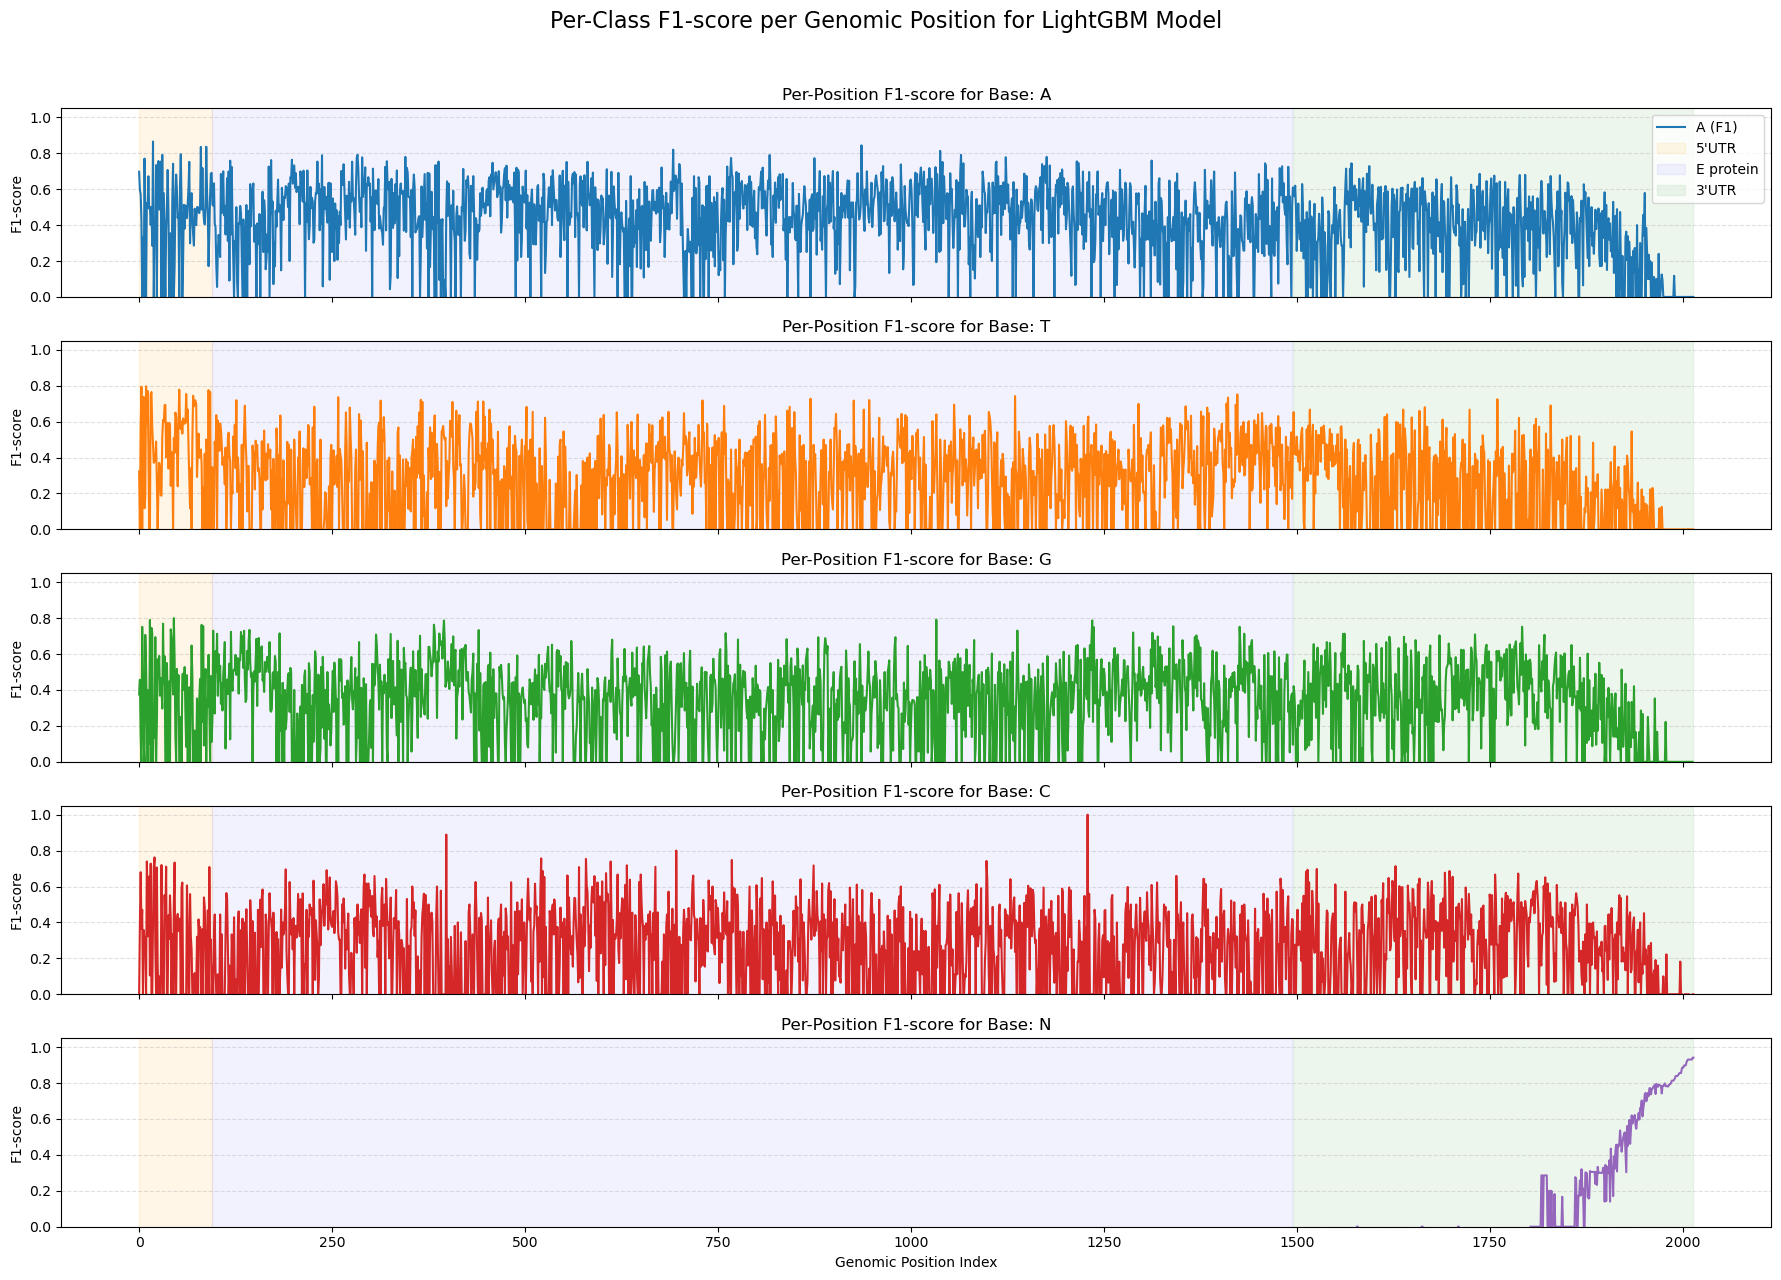

In [16]:
class_labels = {
    '1': 'A',
    '2': 'T',
    '3': 'G',
    '4': 'C',
    '0': 'N'
}
class_keys = ['1','2','3','4','0']
f1_matrix = report_df[[f'f1_{key}' for key in class_keys]].values

n_classes = len(class_keys)
fig, axes = plt.subplots(n_classes, 1, figsize=(18, 2.5 * n_classes), sharex=True, sharey=True)

for idx, key in enumerate(class_keys):
    ax = axes[idx]
    ax.plot(range(len(report_df)), f1_matrix[:, idx], label=f"{class_labels[key]} (F1)", color='C'+str(idx))
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-Position F1-score for Base: {class_labels[key]}")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax.axvspan(utr5_start, utr5_end, color='orange', alpha=0.09, label="5'UTR" if idx==0 else None)
    ax.axvspan(e_start, e_end, color='blue', alpha=0.05, label="E protein" if idx==0 else None)
    ax.axvspan(utr3_start, utr3_end, color='green', alpha=0.07, label="3'UTR" if idx==0 else None)
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Genomic Position Index")
plt.suptitle("Per-Class F1-score per Genomic Position for LightGBM Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analysis of Per-Class F1-score per Genomic Position for LightGBM Model

The above figure presents the per-position F1-score for each nucleotide base (A, T, G, C, N) as predicted by the LightGBM model, covering the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. Each subplot corresponds to a specific nucleotide class, with colored backgrounds indicating the major genomic regions.

#### Key Insights:

- **Consistently strong per-class F1-scores:**  
  The model achieves high and stable F1-scores for the major nucleotide bases (A, T, G, C) across most genomic positions, frequently exceeding 0.4–0.5. This demonstrates the LightGBM model’s robust capability for accurate, balanced multi-class nucleotide prediction using only environmental features.

- **Base-specific performance and variability:**  
  While overall performance is strong, some variation exists between classes and across positions. Occasional dips in F1-score may correspond to sites with rare nucleotides or high biological variability, yet LightGBM maintains relatively high performance even at these challenging positions.

- **‘N’ base artifact:**  
  The F1-score for the ‘N’ (padding/unknown) base remains near zero across most of the genome, but rises sharply at the distal end of the 3′UTR. This increase reflects technical padding from sequence alignment, rather than true biological prediction.

- **Consistency across regions:**  
  The model’s high per-class F1-scores are maintained throughout the 5′UTR, E protein, and 3′UTR regions, indicating LightGBM’s generalizability and strong multi-class discrimination across functionally diverse segments of the genome.

#### Heatmap for Confusion Matrix

In [17]:
# Merge to associate macro_f1 with each confusion matrix
merged_df = pd.merge(report_df[['position', 'macro_f1']], conf_matrix_df, on='position')

base_labels = ['N', 'A', 'T', 'G', 'C']

def plot_conf_matrices_grid(df, positions, base_labels, fig_title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for idx, pos in enumerate(positions):
        cm = np.array(df[df['position'] == pos]['confusion_matrix'].values[0])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=base_labels, yticklabels=base_labels, 
                    ax=axes[idx], cbar=False)
        axes[idx].set_title(f"{pos}")
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')
    # Hide any unused subplots (if less than 10)
    for i in range(len(positions), 10):
        axes[i].axis('off')
    plt.suptitle(fig_title, fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

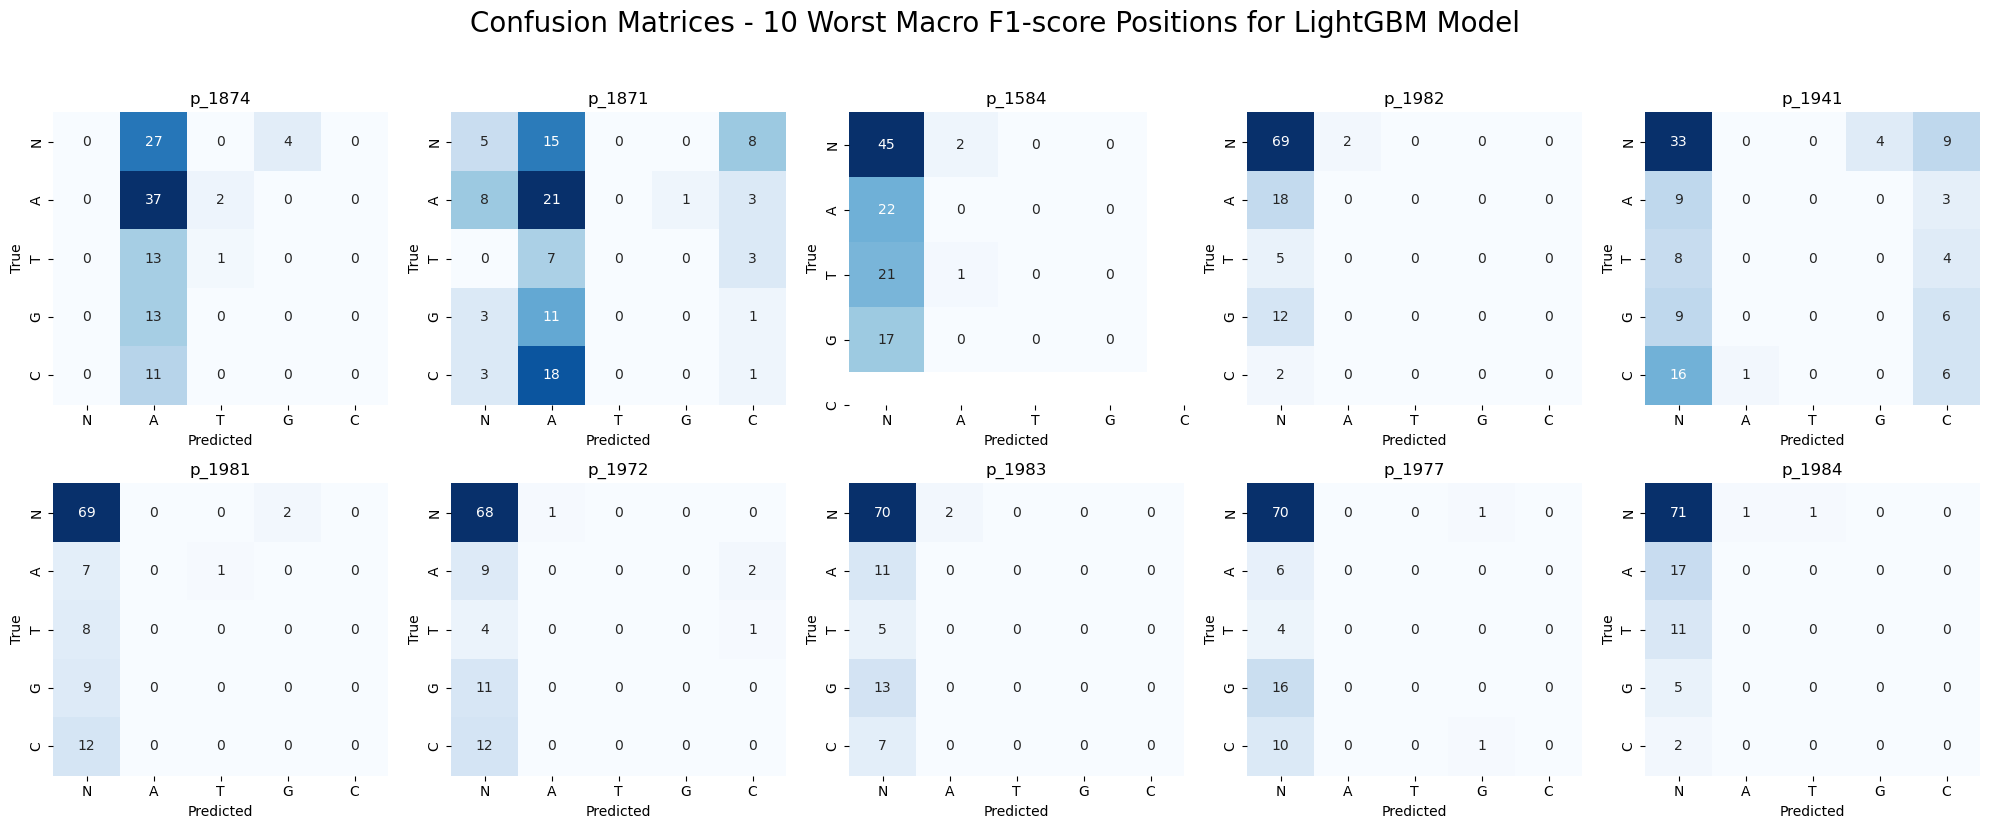

In [18]:
# 10 worst F1-score positions
worst_10 = merged_df.nsmallest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, worst_10, base_labels, "Confusion Matrices - 10 Worst Macro F1-score Positions for LightGBM Model")

### Analysis of Confusion Matrices — 10 Worst Macro F1-score Positions for LightGBM Model

The above figure displays confusion matrices for the 10 nucleotide positions with the lowest macro F1-scores in the LightGBM model. Each matrix summarizes the correspondence between true and predicted nucleotide classes (N, A, T, G, C) at a single genomic position, highlighting the genomic sites where the model encountered the greatest predictive challenge.

#### Key Insights:

- **Substantial misclassification:**  
  Many of these matrices show heavy off-diagonal elements, indicating frequent misclassification between nucleotide classes. In some positions, predictions are dominated by a single base (e.g., N or A), regardless of the true label, leading to poor multi-class discrimination.

- **Sparse correct predictions:**  
  Diagonal dominance (indicative of correct predictions) is weak or absent for most of these positions, resulting in low macro F1-scores. This underscores the model’s limited ability to resolve the correct nucleotide class at these sites using only environmental features.

- **High class confusion:**  
  For certain positions, true nucleotides are widely distributed among incorrect predictions, often clustering around one or two classes. This pattern may result from class imbalance, mutation hotspots, or limited informativeness of environmental variables for these genomic sites.

- **Technical and biological factors:**  
  Some matrices reflect a strong bias toward the ‘N’ class (especially in the later genomic positions), which may be a consequence of sequence padding or highly conserved/padded regions, rather than model-specific errors.

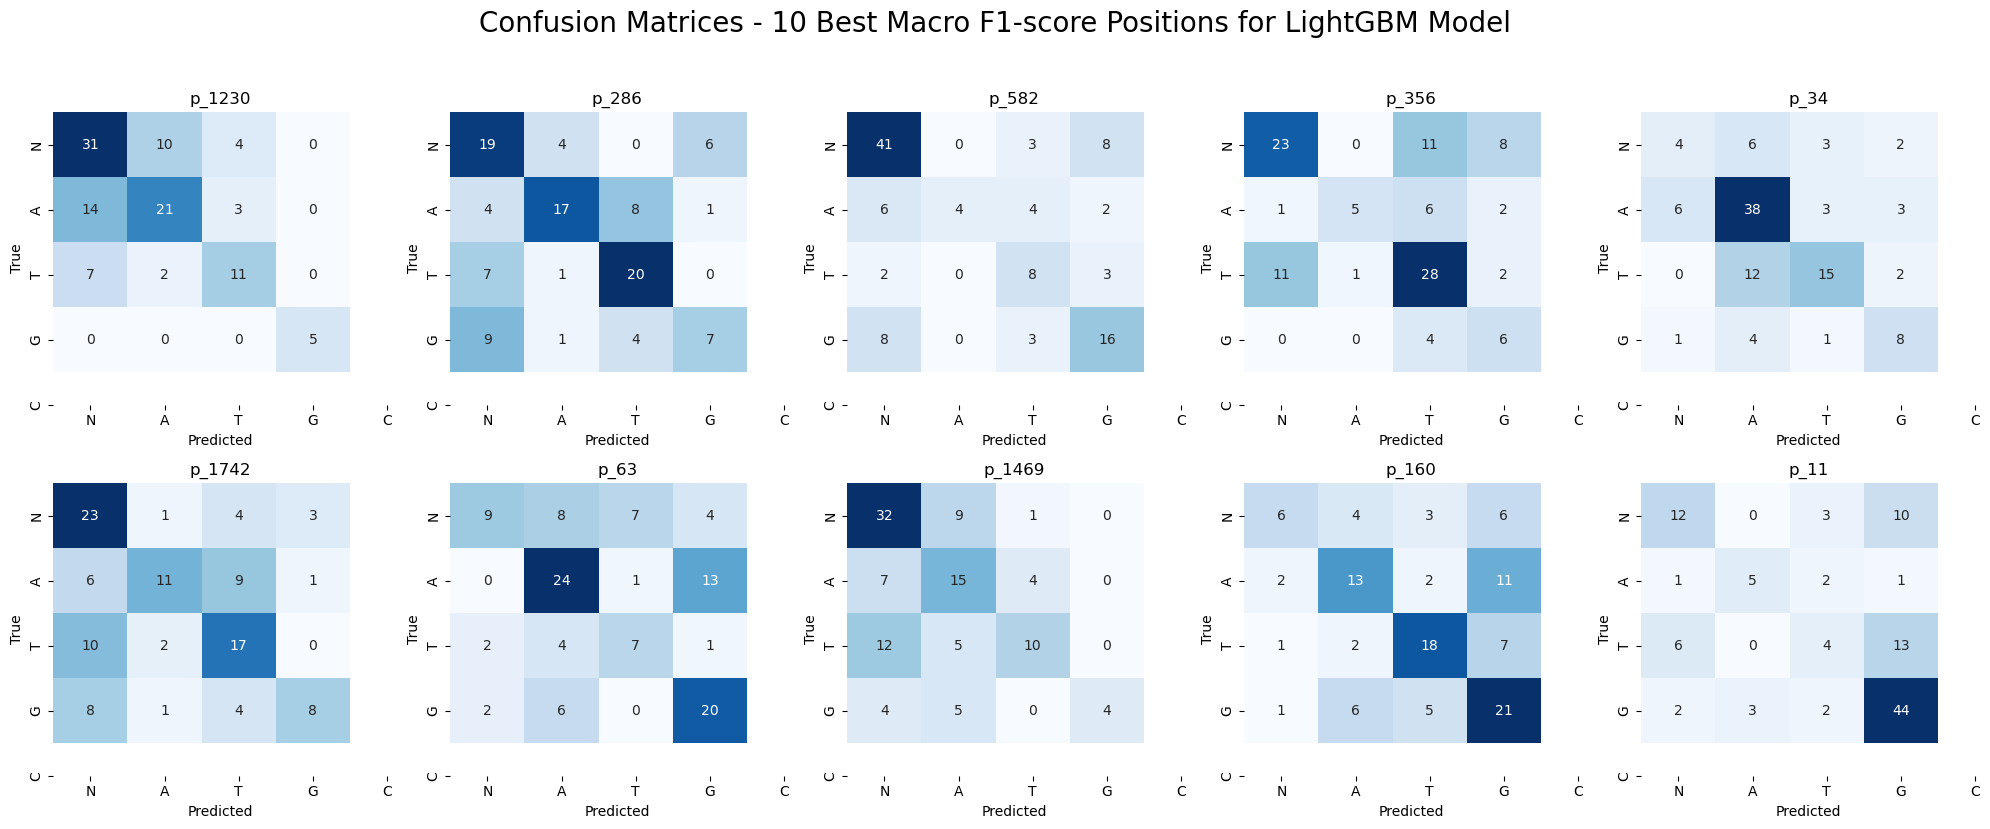

In [19]:
# 10 best F1-score positions
best_10 = merged_df.nlargest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, best_10, base_labels, "Confusion Matrices - 10 Best Macro F1-score Positions for LightGBM Model")

### Analysis of Confusion Matrices — 10 Best Macro F1-score Positions for LightGBM Model

The above figure presents confusion matrices for the 10 nucleotide positions with the highest macro F1-scores in the LightGBM model. Each matrix summarizes the relationship between true and predicted nucleotide classes (N, A, T, G, C) at a single genomic position, providing insight into the model’s peak predictive performance.

#### Key Insights:

- **Strong diagonal dominance:**  
  These confusion matrices are characterized by a high concentration of counts along the main diagonal, indicating that the majority of true nucleotides are correctly predicted by the model. This reflects LightGBM’s strong classification capability at these positions.

- **Robust multi-class discrimination:**  
  The model demonstrates a clear ability to distinguish among all four major nucleotide classes (A, T, G, C), with only minor off-diagonal misclassifications. The distribution of predictions is well-aligned with the true class distribution, which supports high macro F1-scores.

- **Minimal class confusion:**  
  Misclassification rates are low, and off-diagonal cells generally have much smaller counts than diagonal cells. Where misclassifications do occur, they are typically limited to neighboring or biochemically similar bases, suggesting that the model effectively captures relevant sequence patterns and environmental influences.

- **Consistency across sites:**  
  The high accuracy and balanced performance observed in these positions suggest that LightGBM is particularly effective at genomic sites where environmental predictors are highly informative or where sequence patterns are less complex.

- **Implications for genomic prediction:**  
  These matrices exemplify the upper bound of model performance, highlighting genomic positions where the integration of environmental variables and gradient boosting achieves the greatest success in nucleotide forecasting.

In [20]:
# Save to CSV (or JSON for confusion matrices)
report_df.to_csv('../results/lgb_per_position_classification_report.csv', index=False)
conf_matrix_df.to_json('../results/lgb_per_position_confusion_matrices.json', orient='records')

### Save the model

In [21]:
joblib.dump(lgb_multi, '../models/lgb_multioutput_model.joblib')

['../models/lgb_multioutput_model.joblib']